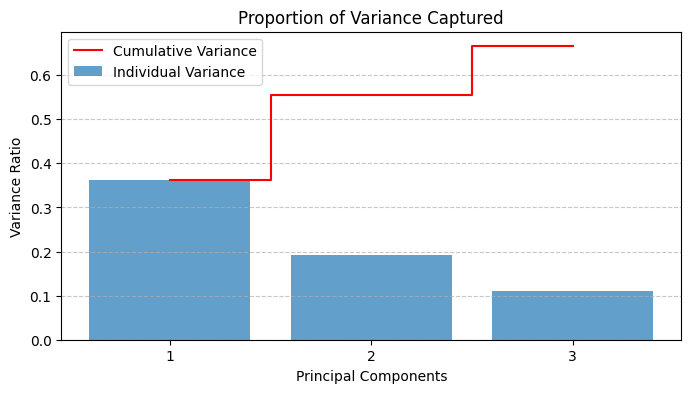

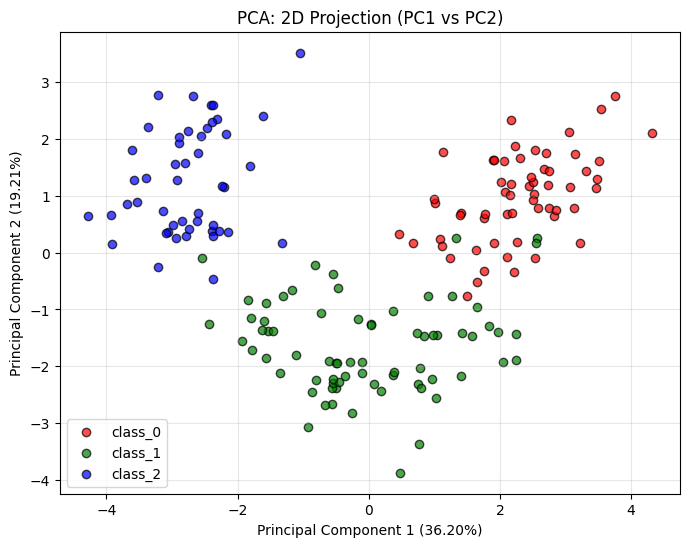

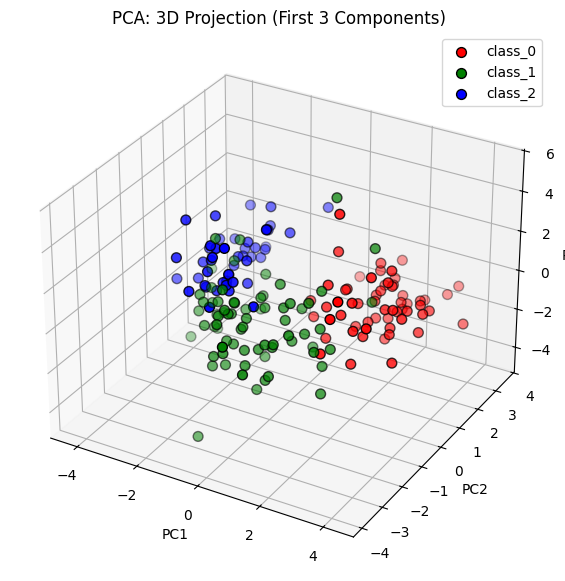

Total Variance captured by 3 components: 66.53%


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

# 1. Load the Wine Dataset
wine = load_wine()
X = wine.data
y = wine.target
target_names = wine.target_names

# 2. Standardize the data (Mean=0, Variance=1)
# This is crucial for PCA!
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Perform PCA (Reduce 13 dimensions to 3)
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

# --- VISUALIZATION 1: Scree Plot (Explained Variance) ---
exp_var = pca.explained_variance_ratio_
cum_var = np.cumsum(exp_var)

plt.figure(figsize=(8, 4))
plt.bar(range(1, 4), exp_var, alpha=0.7, label='Individual Variance')
plt.step(range(1, 4), cum_var, where='mid', label='Cumulative Variance', color='red')
plt.title('Proportion of Variance Captured')
plt.xlabel('Principal Components')
plt.ylabel('Variance Ratio')
plt.xticks([1, 2, 3])
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# --- VISUALIZATION 2: 2D Projection ---
plt.figure(figsize=(8, 6))
colors = ['r', 'g', 'b']
for i, color, name in zip(range(3), colors, target_names):
    plt.scatter(X_pca[y == i, 0], X_pca[y == i, 1], c=color, label=name, edgecolors='k', alpha=0.7)

plt.title('PCA: 2D Projection (PC1 vs PC2)')
plt.xlabel(f'Principal Component 1 ({exp_var[0]:.2%})')
plt.ylabel(f'Principal Component 2 ({exp_var[1]:.2%})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# --- VISUALIZATION 3: 3D Projection ---
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

for i, color, name in zip(range(3), colors, target_names):
    ax.scatter(X_pca[y == i, 0], X_pca[y == i, 1], X_pca[y == i, 2], 
               c=color, label=name, edgecolors='k', s=50)

ax.set_title('PCA: 3D Projection (First 3 Components)')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.legend()
plt.show()

# Print the summary
print(f"Total Variance captured by 3 components: {cum_var[2]:.2%}")